### Text Classifications


In [ ]:
print('Everything is okey!!!')

Everything is okey!!!


In [ ]:
#!pip install transformers==4.57.6 datasets==2.21.0 accelerate==0.32.1 sentencepiece==0.2.0

In [ ]:
# Import dependancies

import pandas as pd
from transformers import pipeline

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Text classifications with default model

classifier = pipeline("text-classification")

text = "I love to learn GenAI from Anant Verma."

output = classifier(text)

print(output)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

[{'label': 'POSITIVE', 'score': 0.999647855758667}]


In [ ]:
pd.DataFrame(output)

,label,score
0,POSITIVE,0.999648


In [ ]:
# Classification with specified model

classifier = pipeline("text-classification",
model="tabularisai/multilingual-emotion-classification")

text = "I love to learn GenAI from Anant Verma."

output = classifier(text)

print(output)

config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

[{'label': 'love', 'score': 0.9526046514511108}]


In [ ]:
pd.DataFrame(output)

,label,score
0,joy,0.979073


### Token Classifications

1. NER
2. POS

In [ ]:
# NER pipeline

ner = pipeline('ner')

text = 'I am Anant and I live in Noida.'

output = ner(text)

print(output)

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496 (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0


[{'entity': 'I-PER', 'score': 0.99394155, 'index': 3, 'word': 'Ana', 'start': 5, 'end': 8}, {'entity': 'I-PER', 'score': 0.99748224, 'index': 4, 'word': '##nt', 'start': 8, 'end': 10}, {'entity': 'I-LOC', 'score': 0.99755496, 'index': 9, 'word': 'No', 'start': 25, 'end': 27}, {'entity': 'I-LOC', 'score': 0.9966455, 'index': 10, 'word': '##ida', 'start': 27, 'end': 30}]


In [ ]:
pd.DataFrame(output)

,entity,score,index,word,start,end
0,I-PER,0.993942,3,Ana,5,8
1,I-PER,0.997482,4,##nt,8,10
2,I-LOC,0.997555,9,No,25,27
3,I-LOC,0.996646,10,##ida,27,30


In [ ]:
model_card = 'vblagoje/bert-english-uncased-finetuned-pos'

pos_tagger = pipeline('ner',
model = model_card)

output = pos_tagger(text)

pd.DataFrame(output)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of the model checkpoint at vblagoje/bert-english-uncased-finetuned-pos were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


,entity,score,index,word,start,end
0,PRON,0.999511,1,i,0,1
1,AUX,0.998044,2,am,2,4
2,PROPN,0.994122,3,ana,5,8
3,PROPN,0.994280,4,##nt,8,10
4,CCONJ,0.999222,5,and,11,14
5,PRON,0.999493,6,i,15,16
6,VERB,0.999077,7,live,17,21
7,ADP,0.999392,8,in,22,24
8,PROPN,0.998708,9,no,25,27
9,PROPN,0.998797,10,##ida,27,30


In [ ]:
output

[{'entity': 'PRON',
  'score': 0.9995111,
  'index': 1,
  'word': 'i',
  'start': 0,
  'end': 1},
 {'entity': 'AUX',
  'score': 0.99804425,
  'index': 2,
  'word': 'am',
  'start': 2,
  'end': 4},
 {'entity': 'PROPN',
  'score': 0.9941223,
  'index': 3,
  'word': 'ana',
  'start': 5,
  'end': 8},
 {'entity': 'PROPN',
  'score': 0.99427986,
  'index': 4,
  'word': '##nt',
  'start': 8,
  'end': 10},
 {'entity': 'CCONJ',
  'score': 0.9992219,
  'index': 5,
  'word': 'and',
  'start': 11,
  'end': 14},
 {'entity': 'PRON',
  'score': 0.9994931,
  'index': 6,
  'word': 'i',
  'start': 15,
  'end': 16},
 {'entity': 'VERB',
  'score': 0.9990766,
  'index': 7,
  'word': 'live',
  'start': 17,
  'end': 21},
 {'entity': 'ADP',
  'score': 0.99939156,
  'index': 8,
  'word': 'in',
  'start': 22,
  'end': 24},
 {'entity': 'PROPN',
  'score': 0.9987085,
  'index': 9,
  'word': 'no',
  'start': 25,
  'end': 27},
 {'entity': 'PROPN',
  'score': 0.99879706,
  'index': 10,
  'word': '##ida',
  'start': 

### Question-Answering

In [ ]:
# Question Answering pipeline

qa_pipeline = pipeline('question-answering',
model='distilbert-base-cased-distilled-squad',
device=0
)

text = """Large Language Models (LLMs) are advanced AI systems built on deep neural networks designed to process, understand and generate human-like text.

LLMs Learn patterns, grammar and context from text and can answer questions, write content, translate languages and many more.
By using massive datasets and billions of parameters, LLMs have transformed the way humans interact with technology.
Modern LLMs include ChatGPT (OpenAI), Google Gemini, Anthropic Claude, etc."""

question = "What is the fullform of LLM?"

output = qa_pipeline(question = question, context = text)

print(output)



config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


{'score': 0.9945473670959473, 'start': 0, 'end': 21, 'answer': 'Large Language Models'}


In [ ]:
pd.DataFrame([output])

,score,start,end,answer
0,0.994547,0,21,Large Language Models


In [ ]:
print(output['answer'])

Large Language Models


### Text Summarization

In [ ]:
summarization_pipeline = pipeline('summarization', device=0)

text = """Large language models (LLMs) are a type of Artificial Intelligence (AI) system trained on massive amounts of text data. This allows them to analyze and understand language with proficiency. Natural Language Processing (NLP) is a key area where LLMs excel. They can perform tasks like:

Text generation: Creating human-quality text, translating languages, and writing different kinds of creative content.
Question answering: Providing informative responses to user queries.
Sentiment analysis: Understanding the emotional tone of a piece of text."""

output = summarization_pipeline(text)

print(output)

No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0
Your max_length is set to 142, but your input_length is only 109. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=54)


[{'summary_text': ' Large language models (LLMs) are a type of Artificial Intelligence (AI) system trained on massive amounts of text data . This allows them to analyze and understand language with proficiency . LLMs can perform tasks like creating human-quality text, translating languages, and writing different kinds of creative content .'}]


In [ ]:
pd.DataFrame(output)

,summary_text
0,Large language models (LLMs) are a type of Ar...


In [ ]:
# text summerization with specific model

model = "facebook/bart-large-cnn"

summarization_pipeline = pipeline('summarization', model = model, device=0)

text = """Large language models (LLMs) are a type of Artificial Intelligence (AI) system trained on massive amounts of text data. This allows them to analyze and understand language with proficiency. Natural Language Processing (NLP) is a key area where LLMs excel. They can perform tasks like:

Text generation: Creating human-quality text, translating languages, and writing different kinds of creative content.
Question answering: Providing informative responses to user queries.
Sentiment analysis: Understanding the emotional tone of a piece of text."""

output = summarization_pipeline(text)

print(output)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0
Your max_length is set to 142, but your input_length is only 109. Since this is a summarization task, where outputs shorter than the input are typically wanted, you might consider decreasing max_length manually, e.g. summarizer('...', max_length=54)


[{'summary_text': 'Large language models (LLMs) are a type of Artificial Intelligence (AI) system trained on massive amounts of text data. This allows them to analyze and understand language with proficiency. LLMs can perform tasks like creating human-quality text, translating languages, and writing different kinds of creative content.'}]


### Translations

In [ ]:
# Machine translation english to german

mt_en_de = pipeline('translation_en_to_de', device=0)

text = """Large language models (LLMs) are a type of Artificial Intelligence (AI) system trained on massive amounts of text data. This allows them to analyze and understand language with proficiency. Natural Language Processing (NLP) is a key area where LLMs excel. They can perform tasks like:

Text generation: Creating human-quality text, translating languages, and writing different kinds of creative content.
Question answering: Providing informative responses to user queries.
Sentiment analysis: Understanding the emotional tone of a piece of text."""

output = mt_en_de(text)

output

No model was supplied, defaulted to google-t5/t5-base and revision a9723ea (https://huggingface.co/google-t5/t5-base).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


[{'translation_text': 'Große Sprachmodelle (LLMs) sind eine Art von künstlicher Intelligenz (AI) System, das auf massiven Mengen von Textdaten trainiert ist und es ihnen ermöglicht, Sprachen kompetent zu analysieren und zu verstehen.'}]

In [ ]:
# english to hindi

mt_en_hi = pipeline('translation_en_to_hi',
model='Helsinki-NLP/opus-mt-en-hi',
device=0)

text = """Large language models (LLMs) are a type of Artificial Intelligence (AI) system trained on massive amounts of text data. This allows them to analyze and understand language with proficiency. Natural Language Processing (NLP) is a key area where LLMs excel. They can perform tasks like:

Text generation: Creating human-quality text, translating languages, and writing different kinds of creative content.
Question answering: Providing informative responses to user queries.
Sentiment analysis: Understanding the emotional tone of a piece of text."""

output = mt_en_hi(text)

output

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/306M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/306M [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/812k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


[{'translation_text': 'बड़े भाषा के मॉडलों (इन्स) कलात्मक डेटा पर प्रशिक्षित प्रणाली है _BAR_ यह उन्हें स्वाभाविक भाषा प्रक्रिया (NP) के साथ जांच और भाषा समझने की अनुमति देता है _BAR_ प्राकृतिक भाषा प्रक्रिया (NP) एक प्रमुख क्षेत्र है जिसमें सबसे अधिक श्रेष्ठ है _BAR_ वे पाठ बनाने की तरह कार्य कर सकते हैं: मानव भाषा पाठ बनाने, भाषा का अनुवाद करने, भाषा का अनुवाद करने के अलग प्रकार का उपयोग करने, भाषा का उपयोग करने के लिए _BAR_'}]

In [ ]:
# Text generation pipeline

text_generation_pipe = pipeline('text-generation')

text = 'The large language models are'

output = text_generation_pipe(text)

output


No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': 'The large language models are extremely well defined and can be used for building a large set of data representations for various scenarios.\n\nFor example, if you are looking at a large set of data, you can use the large language models to create data structures that can represent thousands of different data types. The large language models can be used to create a large set of data structures that can be used to represent tens of thousands of different data types.\n\nFor example, if you are looking at a large set of data, you can use the large language models to create data structures that can represent tens of thousands of different data types.\n\nFor example, if you are looking at a large set of data, you can use the large language models to create data structures that can represent tens of thousands of different data types.\n\nThese models generally have the following features:\n\nThey are used to create data structures that can represent tens of thousands of d

In [ ]:
output = text_generation_pipe('Write a story about a robot.', max_length=128)

output

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Both `max_new_tokens` (=256) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Write a story about a robot.\n\nIn January, the Federal Bureau of Investigation was given an entire year to investigate the death of a former employee of the software firm Baidu.\n\nIn a written statement to The Wall Street Journal, a Baidu spokesperson said: "Baidu has been in the news for some time and we are committed to addressing any and all investigations and inquiries relating to our operations and results of operations."\n\nThe company is also investigating a former Baidu employee who was killed in a car crash in September 2015.\n\nThe company is also investigating whether Baidu\'s financial statements contained information that could have led to the death of the former worker, an FBI source told the Journal.\n\nAn internal Baidu memo cited by the Journal said employees in the company knew of the death of the former employee, and that the company knew of the fatal accident, but chose not to provide details.\n\nAfter the employee\'s death, Baidu said in a st

In [ ]:
# Text generation pipeline

text_generation_pipe = pipeline('text-generation', model = 'openai-community/gpt2-xl')

text = 'The large language models are'

output = text_generation_pipe(text)

output

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': 'The large language models are written in Python.\n\nThe large data models are written in R.\n\nThe large image models are written in TensorFlow.\n\nThe large text models are written in Python.\n\nThe large graph models are written in TensorFlow.\n\nThe large image model is written in TensorFlow.\n\nThe large text model is written in TensorFlow.\n\nThe large image model is written in TensorFlow.\n\nThe large text model is written in TensorFlow.\n\nThe large graph model is written in TensorFlow.\n\nThe large image model is written in TensorFlow.\n\nThe large text model is written in TensorFlow.\n\nThe large graph model is written in TensorFlow.\n\nThe large text model is written in TensorFlow.\n\nThe large image model is written in TensorFlow.\n\nThe large text model is written in TensorFlow.\n\nThe large graph model is written in TensorFlow.\n\nThe large text model is written in TensorFlow.\n\nThe large image model is written in TensorFlow.\n\nThe large text model i

In [ ]:
from PIL import Image
import requests

In [ ]:
# Image classifications



url = 'https://upload.wikimedia.org/wikipedia/commons/d/d0/German_Shepherd_-_DSC_0346_%2810096362833%29.jpg'
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)'}
image = Image.open(requests.get(url, headers=headers, stream=True).raw)

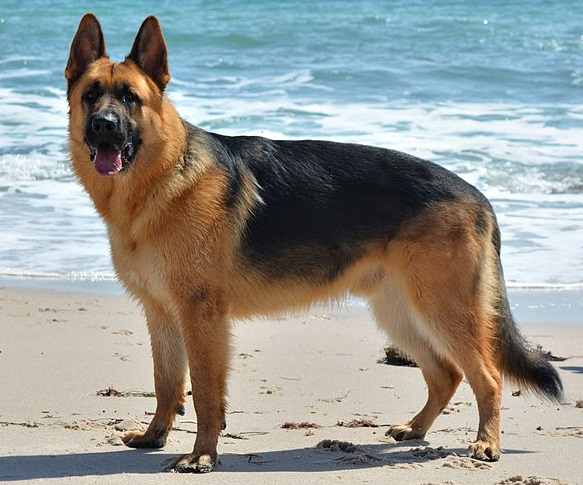

In [ ]:
image

In [ ]:
# Image classifications

image_classification_pipe = pipeline('image-classification')

output = image_classification_pipe(image)

output

No model was supplied, defaulted to google/vit-base-patch16-224 and revision 3f49326 (https://huggingface.co/google/vit-base-patch16-224).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Device set to use cuda:0


[{'label': 'German shepherd, German shepherd dog, German police dog, alsatian',
  'score': 0.9873785376548767},
 {'label': 'kelpie', 'score': 0.0025156885385513306},
 {'label': 'malinois', 'score': 0.0009707462158985436},
 {'label': 'dingo, warrigal, warragal, Canis dingo',
  'score': 0.0008986141183413565},
 {'label': 'bloodhound, sleuthhound', 'score': 0.0005087154568172991}]

In [ ]:
# Image classifications

image_classification_pipe = pipeline('image-classification', model = 'microsoft/resnet-18')

output = image_classification_pipe(image)

output

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


[{'label': 'German shepherd, German shepherd dog, German police dog, alsatian',
  'score': 0.9984065890312195},
 {'label': 'bloodhound, sleuthhound', 'score': 0.0004891609423793852},
 {'label': 'Tibetan mastiff', 'score': 0.00028096712776459754},
 {'label': 'Leonberg', 'score': 0.0001798775774659589},
 {'label': 'Norwegian elkhound, elkhound', 'score': 0.00010892495629377663}]

In [ ]:
# Image Segmentation

segmentation_pipeline = pipeline("image-segmentation")

output = segmentation_pipeline(image)

output

No model was supplied, defaulted to facebook/detr-resnet-50-panoptic and revision d53b52a (https://huggingface.co/facebook/detr-resnet-50-panoptic).
Using a pipeline without specifying a model name and revision in production is not recommended.
Some weights of the model checkpoint at facebook/detr-resnet-50-panoptic were not used when initializing DetrForSegmentation: ['detr.model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'detr.model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'detr.model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'detr.model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForSegmentation from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrFor

[{'score': 0.998933,
  'label': 'sand',
  'mask': <PIL.Image.Image image mode=L size=583x485>},
 {'score': 0.996925,
  'label': 'sea',
  'mask': <PIL.Image.Image image mode=L size=583x485>},
 {'score': 0.999229,
  'label': 'dog',
  'mask': <PIL.Image.Image image mode=L size=583x485>}]

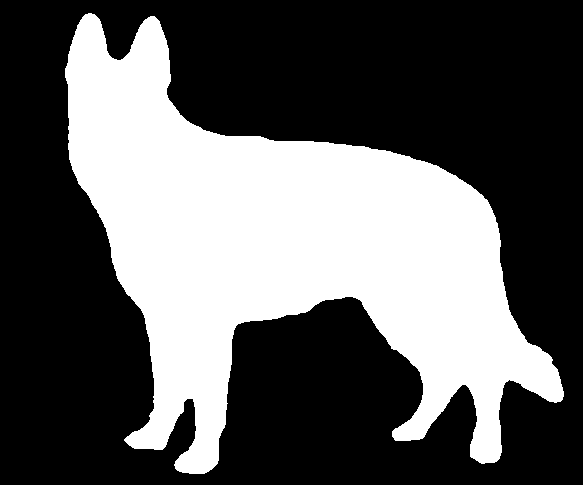

In [ ]:
output[2]['mask']

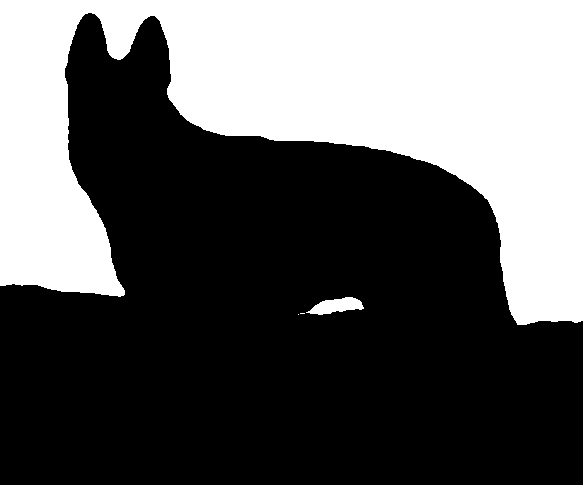

In [ ]:
output[1]['mask']

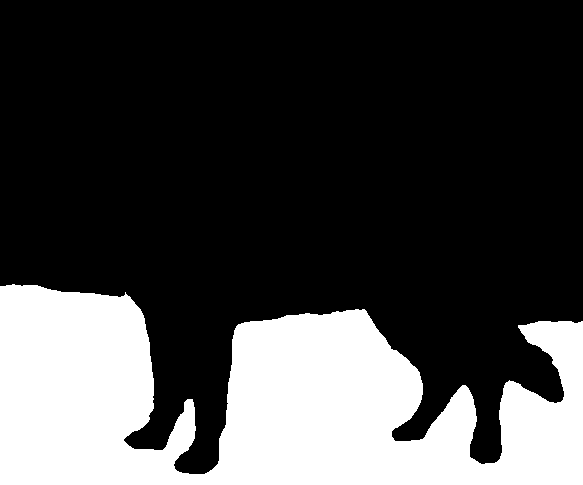

In [ ]:
output[0]['mask']

In [ ]:
# Image Segmentation

segmentation_pipeline = pipeline("image-segmentation", model_checkpoint ='nvidia/segformer-b0-finetuned-ade-512-512')

output = segmentation_pipeline(image)

output

No model was supplied, defaulted to facebook/detr-resnet-50-panoptic and revision d53b52a (https://huggingface.co/facebook/detr-resnet-50-panoptic).
Using a pipeline without specifying a model name and revision in production is not recommended.
Some weights of the model checkpoint at facebook/detr-resnet-50-panoptic were not used when initializing DetrForSegmentation: ['detr.model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'detr.model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'detr.model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'detr.model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForSegmentation from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrFor

[{'score': 0.998933,
  'label': 'sand',
  'mask': <PIL.Image.Image image mode=L size=583x485>},
 {'score': 0.996925,
  'label': 'sea',
  'mask': <PIL.Image.Image image mode=L size=583x485>},
 {'score': 0.999229,
  'label': 'dog',
  'mask': <PIL.Image.Image image mode=L size=583x485>}]

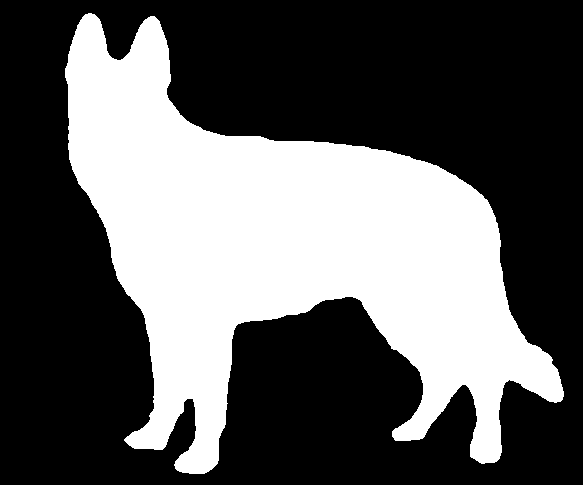

In [ ]:
output[2]['mask']

In [ ]:
# Text to Speech
import soundfile as sf

tts_pipeline = pipeline('text-to-speech')

text = """Large language models (LLMs) are a type of Artificial Intelligence (AI) system trained on massive amounts of text data. This allows them to analyze and understand language with proficiency. Natural Language Processing (NLP) is a key area where LLMs excel. They can perform tasks like:

Text generation: Creating human-quality text, translating languages, and writing different kinds of creative content.
Question answering: Providing informative responses to user queries.
Sentiment analysis: Understanding the emotional tone of a piece of text."""

output = tts_pipeline(text)

output

No model was supplied, defaulted to suno/bark-small and revision 1dbd7a1 (https://huggingface.co/suno/bark-small).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


{'audio': array([[-0.01999045, -0.01986898, -0.0186921 , ..., -0.01999079,
         -0.01103001,  0.02465217]], dtype=float32),
 'sampling_rate': 24000}

In [ ]:
sf.write('speech.wav', output['audio'].T, samplerate=output['sampling_rate'])

In [ ]:
# Music Generations
import soundfile as sf

music_pipeline = pipeline('text-to-audio')

text = 'a chill song with influences from lopi, chilstep and downtempo'

output = music_pipeline(text)

sf.write('music.wav', output['audio'].T, samplerate=output['sampling_rate'])

In [ ]:
# Music Generations
import soundfile as sf

music_pipeline = pipeline('text-to-audio', model='facebook/musicgen-small')

text = 'a chill song with influences from lopi, chilstep and downtempo'

output = music_pipeline(text)

sf.write('music.wav', output['audio'].T, samplerate=output['sampling_rate'])


config.json:   0%|          | 0.00/7.87k [00:00<?, ?B/s]

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.
[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 2047), got 2048. This may result in unexpected behavior.


model.safetensors: reconstructing file:   0%|          |  0.00B / 2.36GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/611 [00:00<?, ?it/s]

...

spiece.model: reconstructing file:   0%|          |  0.00B /  792kB            

spiece.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]